In [12]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [13]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [14]:
len(words)

32033

In [15]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [16]:
# dataset

block_size = 3
X, Y =[], []
for w in words:

    #print(w)
    context = [0]*block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [17]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [44]:
# building the dataset and splitting the data

def build_dataset(words):
    block_size = 3
    X, Y = [], []
    for w in words:

        context =[0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape , Y.shape)
    return X, Y
    
import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [19]:
C = torch.randn((27, 2))

In [20]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [21]:
w1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [22]:
# torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape    inefficient way of doing it as its creating a new tensor. 

In [23]:
# torch.cat(torch.unbind(emb, 1), 1).shape

In [24]:
h = torch.tanh(emb.view(-1, 6) @ w1 + b1)    # -1 is used to infer the size of the first dimension based on the total number of elements and the size of the other dimensions.
                                            #Also broadcasting happens here.

In [25]:
h

tensor([[-0.8344, -0.9895,  0.9035,  ..., -0.3670, -0.9852,  0.5045],
        [-0.7818, -0.7960,  0.9173,  ...,  0.9159, -0.9923, -0.1023],
        [ 0.9673,  0.8909,  0.9487,  ...,  0.9995, -0.9995, -0.0528],
        ...,
        [-0.9428, -0.9002,  0.4343,  ..., -0.9641, -0.9642, -0.0308],
        [-0.9984, -0.9924,  0.9975,  ..., -0.8908, -0.9755, -0.8734],
        [-0.0212, -0.6339, -0.2576,  ...,  0.6980, -0.9900,  0.7777]])

In [26]:
h.shape

torch.Size([228146, 100])

In [27]:
w2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [28]:
logits = h @ w2 + b2

In [29]:
logits.shape

torch.Size([228146, 27])

In [30]:
counts = logits.exp()

In [31]:
prob = counts / counts.sum(1, keepdim=True)

In [32]:
prob.shape

torch.Size([228146, 27])

### Creating the forward pass, backward pass and updating the parameters to reduce loss

In [50]:
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [125]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g)
w1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
w2 = torch.rand((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, w1, w2, b1, b2]

In [126]:
sum(p.nelement() for p in parameters)

11897

In [127]:
for p in parameters:
    p.requires_grad = True

In [115]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [128]:
lri = []
lossi = []
stepi = []

In [129]:
for i in range(200000):
    
    # minibatch
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    # Forward pass
    emb = C[Xtr[ix]]   # [32, 3, 2]
    h = torch.tanh(emb.view(-1,30) @w1 +b1)   # [32, 100]
    logits = h @ w2 + b2        # [32, 27]
    
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdim=True)
    # loss =  -prob[torch.arange(32), Y].log().mean()  It is inefficient to create all these tensors so we use the function so we use the function below to find the loss from the input logits and the target Y.
    loss = F.cross_entropy(logits, Ytr[ix])


    # Backward pass
    for p in parameters:
        p.grad = None       # to prevent accumulation of gradients from previous iterations
    loss.backward()
    # Update
    #lr =lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #tracking stats
    #lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

#print(loss.item())

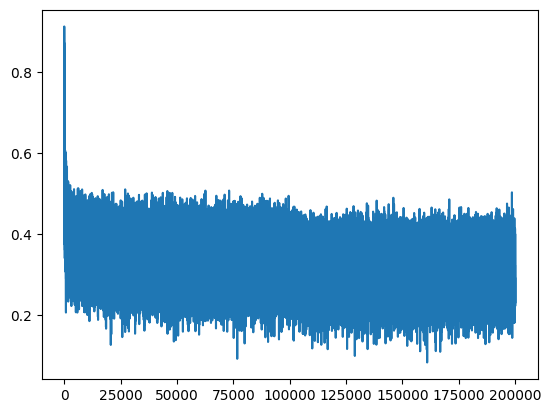

In [130]:
plt.plot(stepi, lossi)

In [131]:
emb = C[Xtr]   
h = torch.tanh(emb.view(-1,30) @w1 +b1)  
logits = h @ w2 + b2 
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0687, grad_fn=<NllLossBackward0>)

In [132]:
emb = C[Xdev]   
h = torch.tanh(emb.view(-1,30) @w1 +b1)  
logits = h @ w2 + b2 
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1271, grad_fn=<NllLossBackward0>)

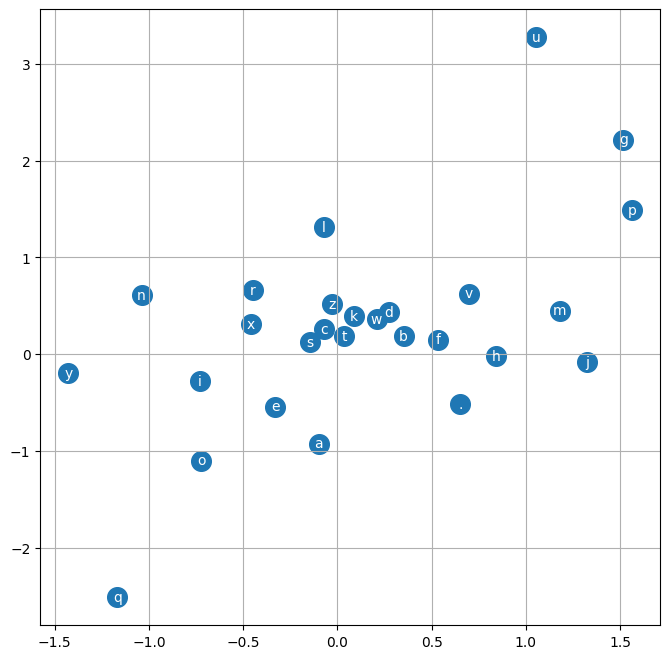

In [111]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

### Sampling from the model

In [134]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix ==0:
            break

    print(''.join(itos[i] for i in out))

carmah.
amille.
khyrichoreetlanna.
sane.
rahnee.
delynn.
jareei.
nellara.
chaiir.
kaleigh.
ham.
jois.
quint.
sulio.
alianni.
waverog.
jarynix.
kael.
dusti.
eddeli.
